In [29]:
!pip install torch torchvision scikit-learn pandas joblib matplotlib



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [30]:
# 🧠 Import libraries
import os, time, joblib
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


Epoch 1/50 | Train Loss: 1193.672577
Epoch 2/50 | Train Loss: 998.997026
Epoch 2/50 | Train Loss: 998.997026
Epoch 3/50 | Train Loss: 983.689987
Epoch 3/50 | Train Loss: 983.689987
Epoch 4/50 | Train Loss: 977.427439
Epoch 4/50 | Train Loss: 977.427439
Epoch 5/50 | Train Loss: 974.221229
Epoch 5/50 | Train Loss: 974.221229
Epoch 6/50 | Train Loss: 971.416986
Epoch 6/50 | Train Loss: 971.416986
Epoch 7/50 | Train Loss: 969.146657
Epoch 7/50 | Train Loss: 969.146657
Epoch 8/50 | Train Loss: 966.760663
Epoch 8/50 | Train Loss: 966.760663
Epoch 9/50 | Train Loss: 965.181681
Epoch 9/50 | Train Loss: 965.181681
Epoch 10/50 | Train Loss: 963.590103
Epoch 10/50 | Train Loss: 963.590103
Epoch 11/50 | Train Loss: 961.907721
Epoch 11/50 | Train Loss: 961.907721
Epoch 12/50 | Train Loss: 960.678007
Epoch 12/50 | Train Loss: 960.678007
Epoch 13/50 | Train Loss: 959.338824
Epoch 13/50 | Train Loss: 959.338824
Epoch 14/50 | Train Loss: 957.979986
Epoch 14/50 | Train Loss: 957.979986
Epoch 15/50 | Tra

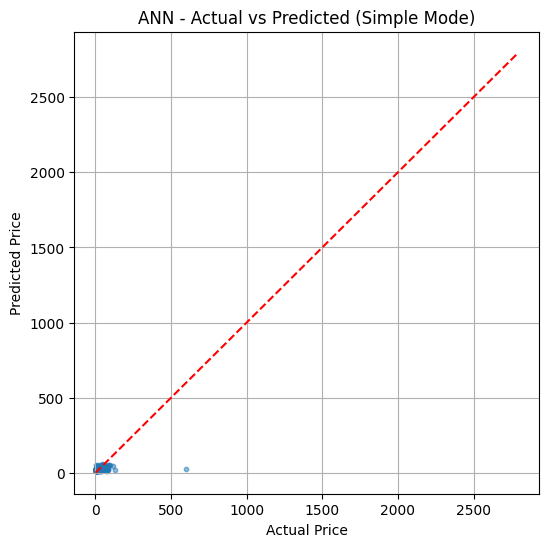

💾 Predictions saved to 'predicted_prices_simple_ann.csv'


In [31]:

# 1️⃣ Load data
df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# 2️⃣ Extract simple numeric features
text_col = "catalog_content"
target_col = "price"

df[text_col] = df[text_col].fillna("").astype(str)
test_df[text_col] = test_df[text_col].fillna("").astype(str)

def make_features(s):
    s = s.fillna("").astype(str)
    return np.vstack([
        s.str.len().values,          # number of characters
        s.str.split().map(len).values,  # number of words
        s.str.count(r"\d").values,   # count of digits
        s.str.count(",").values,     # count of commas
        s.str.count("\\.").values     # count of periods
    ]).T

X_train_num = make_features(df[text_col])
X_test_num = make_features(test_df[text_col])

# Add sample_id as numeric feature
X_train_num = np.hstack([X_train_num, df["sample_id"].values.reshape(-1, 1)])
X_test_num = np.hstack([X_test_num, test_df["sample_id"].values.reshape(-1, 1)])

y = df["price"].values.astype(np.float32)

# 3️⃣ Split dataset
X_train, X_val, y_train, y_val = train_test_split(X_train_num, y, test_size=0.2, random_state=42)

# 4️⃣ Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test_num)

# 5️⃣ Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

# 6️⃣ Define a small ANN
class SimpleANN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x): return self.net(x)

model = SimpleANN(X_train.shape[1])

# 7️⃣ Training setup (robust)
# set deterministic seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
EPOCHS = 50
BATCH_SIZE = 256

# ensure batch size not larger than dataset
batch_size = min(BATCH_SIZE, max(1, X_train_t.size(0)))
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)

# 8️⃣ Train model
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    avg_loss = total_loss / len(train_loader.dataset)

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)
        # compute RMSE on validation (use squared=False)
        #val_rmse = mean_squared_error(y_val_t.numpy().ravel(), val_pred.numpy().ravel(), squared=False)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_loss:.6f}")

# 9️⃣ Final evaluation (single consistent block)
model.eval()
with torch.no_grad():
    y_val_pred = model(X_val_t).numpy().ravel()

#rmse = mean_squared_error(y_val, y_val_pred, squared=False)
mae = mean_absolute_error(y_val, y_val_pred)
r2 = r2_score(y_val, y_val_pred)

#print(f"\n✅ Validation RMSE: {rmse:.3f}")
print(f"✅ Validation MAE: {mae:.3f}")
print(f"✅ Validation R²: {r2:.3f}")

plt.figure(figsize=(6,6))
plt.scatter(y_val[:300], y_val_pred[:300], s=10, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "r--")
plt.xlabel("Actual Price"); plt.ylabel("Predicted Price")
plt.title("ANN - Actual vs Predicted (Simple Mode)"); plt.grid(True); plt.show()

# 🔟 Predict on test set and save
with torch.no_grad():
    y_test_pred = model(X_test_t).numpy().ravel()

# ensure dtype matches expectations
test_df["predicted_price"] = y_test_pred
test_df.to_csv("predicted_prices_simple_ann.csv", index=False)
print("💾 Predictions saved to 'predicted_prices_simple_ann.csv'")
